Tutorial Examaple: Multi-modal RAG: Chat with Docs containing Images - https://www.youtube.com/watch?v=Rg35oYuus-w

In [1]:
from llama_index.core import  SimpleDirectoryReader
from llama_index.core.indices import MultiModalVectorStoreIndex, VectorStoreIndex
from llama_index.vector_stores.chroma import ChromaVectorStore
from llama_index.core import StorageContext, load_index_from_storage
from chromadb.utils.embedding_functions import OpenCLIPEmbeddingFunction
from chromadb.utils.data_loaders import ImageLoader
from llama_index.embeddings.clip import ClipEmbedding
from llama_index.multi_modal_llms.ollama import OllamaMultiModal
from llama_index.core.schema import ImageNode
from llama_index.core.response.notebook_utils import display_source_node, display_image_uris
from llama_index.core.prompts import PromptTemplate
import chromadb
import ollama

In [2]:
embedding_function = OpenCLIPEmbeddingFunction()

In [3]:
image_loader = ImageLoader()

In [4]:
# clip embedder
embed_model = ClipEmbedding()

In [5]:
# create client and a new collection
chroma_client = chromadb.PersistentClient(path="../storage")
#chroma_client = chromadb.Client()

In [6]:
txt_collection = chroma_client.get_or_create_collection(name="text_collection", metadata={"hnsw:space": "cosine"}, embedding_function=embedding_function)

In [7]:
# create txt collection
img_collection = chroma_client.get_or_create_collection(name="images_collection", metadata={"hnsw:space": "cosine"}, embedding_function=embedding_function, data_loader=image_loader)

In [8]:
text_store = ChromaVectorStore(chroma_collection=txt_collection)

In [9]:
image_store = ChromaVectorStore(chroma_collection=img_collection)

In [10]:

storage_context = StorageContext.from_defaults(vector_store=text_store, image_store=image_store)

In [11]:
documents = SimpleDirectoryReader("../data/eml_txt_img/").load_data()

In [12]:
# Create the MultiModal index

index = MultiModalVectorStoreIndex.from_documents(
    documents,
    storage_context=storage_context,
    embed_model=embed_model
)

In [13]:
index.storage_context.persist(persist_dir="../storage")

### Load an existing index

In [14]:
# load vector store
# storage_context = StorageContext.from_defaults(vector_store=text_store, image_store=image_store, persist_dir="../storage")
# index = load_index_from_storage(storage_context, embed_model=embed_model)
import os
if os.path.exists("../storage"):
    print("Load index previously saved")
    chroma_client2 = chromadb.PersistentClient(path="../storage")
    txt_collection2 = chroma_client2.get_collection(name="text_collection")
    img_collection2 = chroma_client2.get_collection(name="images_collection")
    text_store2 = ChromaVectorStore(chroma_collection=txt_collection2)
    image_store2 = ChromaVectorStore(chroma_collection=img_collection2)
    storage_contex2 = StorageContext.from_defaults(vector_store=text_store2, image_store=image_store2, persist_dir="../storage")
    index2 = load_index_from_storage(storage_contex2, embed_model=embed_model)

else:
    print("Create new index")



Load index previously saved


### Get Multimodal Retrieval results form some example queries


In [15]:
query_str = "Author of Pink and Red Sandals"
retriever = index2.as_retriever(similarity_top_k=1, image_similarity_top_k=1)
retrieval_results = retriever.retrieve(query_str)

In [16]:
retrieval_results

[NodeWithScore(node=TextNode(id_='dcd33026-53b2-46a9-94ea-1b483baabc37', embedding=None, metadata={'file_path': 'd:\\project_tfg\\pocs\\poc_llamaindex_chromadb\\notebooks\\..\\data\\eml_txt_img\\4.txt', 'file_name': '4.txt', 'file_type': 'text/plain', 'file_size': 113, 'creation_date': '2024-12-04', 'last_modified_date': '2024-12-06'}, excluded_embed_metadata_keys=['file_name', 'file_type', 'file_size', 'creation_date', 'last_modified_date', 'last_accessed_date'], excluded_llm_metadata_keys=['file_name', 'file_type', 'file_size', 'creation_date', 'last_modified_date', 'last_accessed_date'], relationships={<NodeRelationship.SOURCE: '1'>: RelatedNodeInfo(node_id='1c8a5585-c17f-4890-9022-59a9b3623ee0', node_type='4', metadata={'file_path': 'd:\\project_tfg\\pocs\\poc_llamaindex_chromadb\\notebooks\\..\\data\\eml_txt_img\\4.txt', 'file_name': '4.txt', 'file_type': 'text/plain', 'file_size': 113, 'creation_date': '2024-12-04', 'last_modified_date': '2024-12-06'}, hash='37f22a5645816f80d20af

**Node ID:** dcd33026-53b2-46a9-94ea-1b483baabc37<br>**Similarity:** 0.6809632390836425<br>**Text:** Pink and Red Colors Sandals from the Spring and Summer Women's Collection designed by Estela Mada...<br>

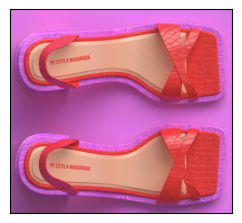

In [17]:
retrieve_imgages = []
for res_nodes in retrieval_results:
    if isinstance(res_nodes.node, ImageNode):
        retrieve_imgages.append(res_nodes.node.metadata["file_path"])
    
    else:
        display_source_node(res_nodes)

display_image_uris(retrieve_imgages, [3, 3], top_k=2)

In [18]:
query_str = "Black Denim Boots"
retriever = index2.as_retriever(similarity_top_k=2, image_similarity_top_k=2)
retrieval_results = retriever.retrieve(query_str)

In [19]:
retrieval_results

[NodeWithScore(node=TextNode(id_='addfa27f-696c-4b4f-80f0-751492a113a9', embedding=None, metadata={'file_path': 'd:\\project_tfg\\pocs\\poc_llamaindex_chromadb\\notebooks\\..\\data\\eml_txt_img\\2.txt', 'file_name': '2.txt', 'file_type': 'text/plain', 'file_size': 151, 'creation_date': '2024-12-04', 'last_modified_date': '2024-12-06'}, excluded_embed_metadata_keys=['file_name', 'file_type', 'file_size', 'creation_date', 'last_modified_date', 'last_accessed_date'], excluded_llm_metadata_keys=['file_name', 'file_type', 'file_size', 'creation_date', 'last_modified_date', 'last_accessed_date'], relationships={<NodeRelationship.SOURCE: '1'>: RelatedNodeInfo(node_id='5d4217a8-1be9-4407-b4f8-6492ea10e5cc', node_type='4', metadata={'file_path': 'd:\\project_tfg\\pocs\\poc_llamaindex_chromadb\\notebooks\\..\\data\\eml_txt_img\\2.txt', 'file_name': '2.txt', 'file_type': 'text/plain', 'file_size': 151, 'creation_date': '2024-12-04', 'last_modified_date': '2024-12-06'}, hash='92cf807ec3c1ec36bc1f8

**Node ID:** addfa27f-696c-4b4f-80f0-751492a113a9<br>**Similarity:** 0.652069412296306<br>**Text:** Black Denim Fabric Cowboy Boots with Red and Pink Floral Embroidery from the Spring and Summer Wo...<br>

**Node ID:** 5b6d7eb0-63f3-4a05-b3bc-b94887b683d9<br>**Similarity:** 0.6506876662087646<br>**Text:** Blue Denim Fabric Cowboy Boots with Camel Floral Embroidery from the Spring and Summer Women's Co...<br>

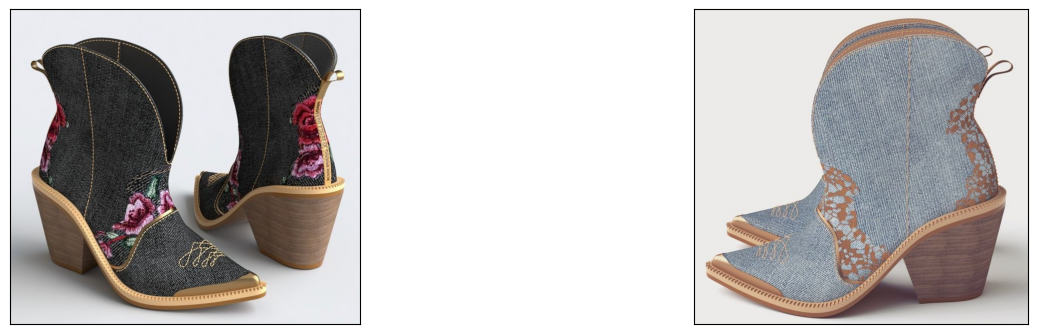

In [20]:
retrieve_imgages = []
for res_nodes in retrieval_results:
    if isinstance(res_nodes.node, ImageNode):
        retrieve_imgages.append(res_nodes.node.metadata["file_path"])
    
    else:
        display_source_node(res_nodes)

display_image_uris(retrieve_imgages, [2, 2], top_k=2)

In [21]:
query_str = "Cowboy Boots"
retriever = index2.as_retriever(similarity_top_k=2, image_similarity_top_k=2)
retrieval_results = retriever.retrieve(query_str)

In [22]:
retrieval_results

[NodeWithScore(node=TextNode(id_='5b6d7eb0-63f3-4a05-b3bc-b94887b683d9', embedding=None, metadata={'file_path': 'd:\\project_tfg\\pocs\\poc_llamaindex_chromadb\\notebooks\\..\\data\\eml_txt_img\\1.txt', 'file_name': '1.txt', 'file_type': 'text/plain', 'file_size': 143, 'creation_date': '2024-12-04', 'last_modified_date': '2024-12-06'}, excluded_embed_metadata_keys=['file_name', 'file_type', 'file_size', 'creation_date', 'last_modified_date', 'last_accessed_date'], excluded_llm_metadata_keys=['file_name', 'file_type', 'file_size', 'creation_date', 'last_modified_date', 'last_accessed_date'], relationships={<NodeRelationship.SOURCE: '1'>: RelatedNodeInfo(node_id='018b1cad-f986-401b-99b9-f7c43ba1dcee', node_type='4', metadata={'file_path': 'd:\\project_tfg\\pocs\\poc_llamaindex_chromadb\\notebooks\\..\\data\\eml_txt_img\\1.txt', 'file_name': '1.txt', 'file_type': 'text/plain', 'file_size': 143, 'creation_date': '2024-12-04', 'last_modified_date': '2024-12-06'}, hash='92c65c86b26ad580c06c8

**Node ID:** 5b6d7eb0-63f3-4a05-b3bc-b94887b683d9<br>**Similarity:** 0.6715627376445755<br>**Text:** Blue Denim Fabric Cowboy Boots with Camel Floral Embroidery from the Spring and Summer Women's Co...<br>

**Node ID:** cd014b68-35ec-4575-aa50-4287776745f5<br>**Similarity:** 0.6468482671050338<br>**Text:** White and Black Colors Mesh Boot from the Spring and Summer Women's Collection designed by Estela...<br>

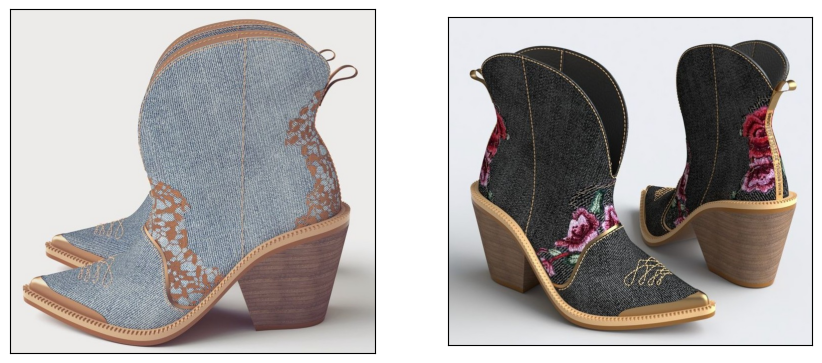

In [23]:
retrieve_imgages = []
for res_nodes in retrieval_results:
    if isinstance(res_nodes.node, ImageNode):
        retrieve_imgages.append(res_nodes.node.metadata["file_path"])
    
    else:
        display_source_node(res_nodes)

display_image_uris(retrieve_imgages, [1, 3], top_k=3)

In [24]:
query_str = "Sneakers"
retriever = index2.as_retriever(similarity_top_k=1, image_similarity_top_k=1)
retrieval_results = retriever.retrieve(query_str)

In [25]:
retrieval_results

[NodeWithScore(node=TextNode(id_='5857a9d7-35cf-4abc-9f6b-d409533e9f4d', embedding=None, metadata={'file_path': 'd:\\project_tfg\\pocs\\poc_llamaindex_chromadb\\notebooks\\..\\data\\eml_txt_img\\5.txt', 'file_name': '5.txt', 'file_type': 'text/plain', 'file_size': 117, 'creation_date': '2024-12-04', 'last_modified_date': '2024-12-06'}, excluded_embed_metadata_keys=['file_name', 'file_type', 'file_size', 'creation_date', 'last_modified_date', 'last_accessed_date'], excluded_llm_metadata_keys=['file_name', 'file_type', 'file_size', 'creation_date', 'last_modified_date', 'last_accessed_date'], relationships={<NodeRelationship.SOURCE: '1'>: RelatedNodeInfo(node_id='fe771f58-6f61-4e6b-9586-b439da3bf8a0', node_type='4', metadata={'file_path': 'd:\\project_tfg\\pocs\\poc_llamaindex_chromadb\\notebooks\\..\\data\\eml_txt_img\\5.txt', 'file_name': '5.txt', 'file_type': 'text/plain', 'file_size': 117, 'creation_date': '2024-12-04', 'last_modified_date': '2024-12-06'}, hash='43ca77b0ccaaa27a37fc0

**Node ID:** 5857a9d7-35cf-4abc-9f6b-d409533e9f4d<br>**Similarity:** 0.6671304245710109<br>**Text:** Peach and White Colors Sneakers from the Spring and Summer Women's Collection designed by Estela ...<br>

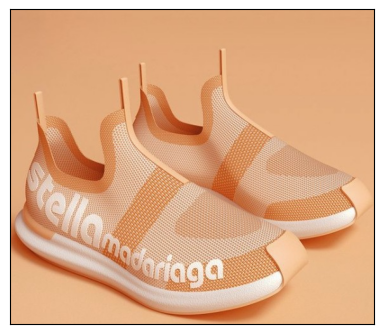

In [26]:
retrieve_imgages = []
for res_nodes in retrieval_results:
    if isinstance(res_nodes.node, ImageNode):
        retrieve_imgages.append(res_nodes.node.metadata["file_path"])
    
    else:
        display_source_node(res_nodes)

display_image_uris(retrieve_imgages, [2, 2], top_k=2)

In [27]:
query_str = "Mesh Boots"
retriever = index2.as_retriever(similarity_top_k=1, image_similarity_top_k=1)
retrieval_results = retriever.retrieve(query_str)

In [28]:
retrieval_results

[NodeWithScore(node=TextNode(id_='cd014b68-35ec-4575-aa50-4287776745f5', embedding=None, metadata={'file_path': 'd:\\project_tfg\\pocs\\poc_llamaindex_chromadb\\notebooks\\..\\data\\eml_txt_img\\3.txt', 'file_name': '3.txt', 'file_type': 'text/plain', 'file_size': 116, 'creation_date': '2024-12-04', 'last_modified_date': '2024-12-06'}, excluded_embed_metadata_keys=['file_name', 'file_type', 'file_size', 'creation_date', 'last_modified_date', 'last_accessed_date'], excluded_llm_metadata_keys=['file_name', 'file_type', 'file_size', 'creation_date', 'last_modified_date', 'last_accessed_date'], relationships={<NodeRelationship.SOURCE: '1'>: RelatedNodeInfo(node_id='6dba4f2b-7f7a-4390-939e-2e43c1064b5b', node_type='4', metadata={'file_path': 'd:\\project_tfg\\pocs\\poc_llamaindex_chromadb\\notebooks\\..\\data\\eml_txt_img\\3.txt', 'file_name': '3.txt', 'file_type': 'text/plain', 'file_size': 116, 'creation_date': '2024-12-04', 'last_modified_date': '2024-12-06'}, hash='361e49f1f4af8e9155ec7

**Node ID:** cd014b68-35ec-4575-aa50-4287776745f5<br>**Similarity:** 0.6891600146585841<br>**Text:** White and Black Colors Mesh Boot from the Spring and Summer Women's Collection designed by Estela...<br>

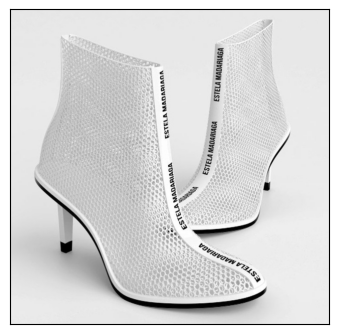

In [29]:
retrieve_imgages = []
for res_nodes in retrieval_results:
    if isinstance(res_nodes.node, ImageNode):
        retrieve_imgages.append(res_nodes.node.metadata["file_path"])
    
    else:
        display_source_node(res_nodes)

display_image_uris(retrieve_imgages, [2, 2], top_k=2)

In [30]:
query_str = "Black Boots"
retriever = index2.as_retriever(similarity_top_k=2, image_similarity_top_k=2)
retrieval_results = retriever.retrieve(query_str)

In [31]:
retrieval_results

[NodeWithScore(node=TextNode(id_='cd014b68-35ec-4575-aa50-4287776745f5', embedding=None, metadata={'file_path': 'd:\\project_tfg\\pocs\\poc_llamaindex_chromadb\\notebooks\\..\\data\\eml_txt_img\\3.txt', 'file_name': '3.txt', 'file_type': 'text/plain', 'file_size': 116, 'creation_date': '2024-12-04', 'last_modified_date': '2024-12-06'}, excluded_embed_metadata_keys=['file_name', 'file_type', 'file_size', 'creation_date', 'last_modified_date', 'last_accessed_date'], excluded_llm_metadata_keys=['file_name', 'file_type', 'file_size', 'creation_date', 'last_modified_date', 'last_accessed_date'], relationships={<NodeRelationship.SOURCE: '1'>: RelatedNodeInfo(node_id='6dba4f2b-7f7a-4390-939e-2e43c1064b5b', node_type='4', metadata={'file_path': 'd:\\project_tfg\\pocs\\poc_llamaindex_chromadb\\notebooks\\..\\data\\eml_txt_img\\3.txt', 'file_name': '3.txt', 'file_type': 'text/plain', 'file_size': 116, 'creation_date': '2024-12-04', 'last_modified_date': '2024-12-06'}, hash='361e49f1f4af8e9155ec7

**Node ID:** cd014b68-35ec-4575-aa50-4287776745f5<br>**Similarity:** 0.6767522549551239<br>**Text:** White and Black Colors Mesh Boot from the Spring and Summer Women's Collection designed by Estela...<br>

**Node ID:** 5b6d7eb0-63f3-4a05-b3bc-b94887b683d9<br>**Similarity:** 0.6118542503294544<br>**Text:** Blue Denim Fabric Cowboy Boots with Camel Floral Embroidery from the Spring and Summer Women's Co...<br>

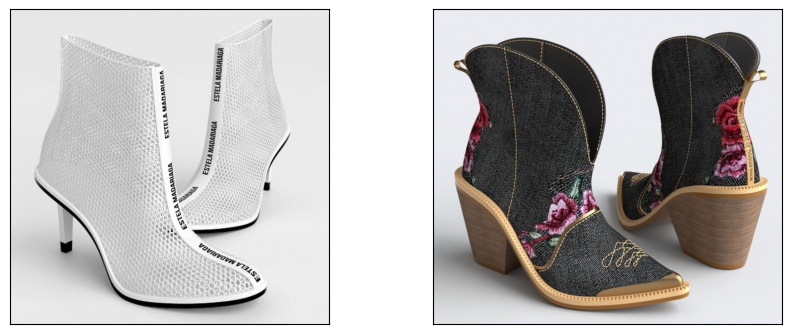

In [32]:
retrieve_imgages = []
for res_nodes in retrieval_results:
    if isinstance(res_nodes.node, ImageNode):
        retrieve_imgages.append(res_nodes.node.metadata["file_path"])
    
    else:
        display_source_node(res_nodes)

display_image_uris(retrieve_imgages, [2, 3], top_k=3)

In [33]:
query_str = "Floral Embroidery"
retriever = index2.as_retriever(similarity_top_k=2, image_similarity_top_k=2)
retrieval_results = retriever.retrieve(query_str)

In [34]:
retrieval_results

[NodeWithScore(node=TextNode(id_='5b6d7eb0-63f3-4a05-b3bc-b94887b683d9', embedding=None, metadata={'file_path': 'd:\\project_tfg\\pocs\\poc_llamaindex_chromadb\\notebooks\\..\\data\\eml_txt_img\\1.txt', 'file_name': '1.txt', 'file_type': 'text/plain', 'file_size': 143, 'creation_date': '2024-12-04', 'last_modified_date': '2024-12-06'}, excluded_embed_metadata_keys=['file_name', 'file_type', 'file_size', 'creation_date', 'last_modified_date', 'last_accessed_date'], excluded_llm_metadata_keys=['file_name', 'file_type', 'file_size', 'creation_date', 'last_modified_date', 'last_accessed_date'], relationships={<NodeRelationship.SOURCE: '1'>: RelatedNodeInfo(node_id='018b1cad-f986-401b-99b9-f7c43ba1dcee', node_type='4', metadata={'file_path': 'd:\\project_tfg\\pocs\\poc_llamaindex_chromadb\\notebooks\\..\\data\\eml_txt_img\\1.txt', 'file_name': '1.txt', 'file_type': 'text/plain', 'file_size': 143, 'creation_date': '2024-12-04', 'last_modified_date': '2024-12-06'}, hash='92c65c86b26ad580c06c8

**Node ID:** 5b6d7eb0-63f3-4a05-b3bc-b94887b683d9<br>**Similarity:** 0.6325053252881823<br>**Text:** Blue Denim Fabric Cowboy Boots with Camel Floral Embroidery from the Spring and Summer Women's Co...<br>

**Node ID:** cd014b68-35ec-4575-aa50-4287776745f5<br>**Similarity:** 0.6013506372617591<br>**Text:** White and Black Colors Mesh Boot from the Spring and Summer Women's Collection designed by Estela...<br>

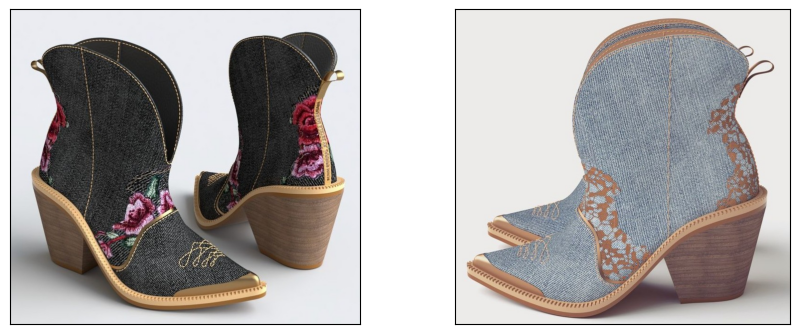

In [35]:
retrieve_imgages = []
for res_nodes in retrieval_results:
    if isinstance(res_nodes.node, ImageNode):
        retrieve_imgages.append(res_nodes.node.metadata["file_path"])
    
    else:
        display_source_node(res_nodes)

display_image_uris(retrieve_imgages, [2, 3], top_k=3)

### Use LLM

* ollama api

In [36]:

respuesta =ollama.chat(
    model="llama3.2-vision:11b",
    messages=[
        {"role": "user", "content": "Describe the image.Respond in spanish","images": ['../data/eml_txt_img/1.jpg']}],
    stream=False
)
print(respuesta['message']['content'])

The image presents a pair of cowboy boots with a unique denim and lace design, set against a light gray background. The purpose of the image appears to be showcasing the boots' stylish and fashionable appeal.

Here are the key features of the image:

* **Boots:**
	+ Made from denim material
	+ Feature a lace design on the upper part of the boot
	+ Have a low heel
	+ Appear to be made for fashion or casual wear rather than heavy-duty work
* **Background:**
	+ Light gray color

Overall, the image effectively showcases the boots' stylish and fashionable appeal, making them suitable for those who want to add a touch of elegance to their outfit.


In [37]:
from llama_index.llms.ollama import Ollama

llm = Ollama(model="llava:7b", request_timeout=60.0)
llm.complete("Cual es la capital de francia?")

CompletionResponse(text=' La capital de Francia est Paris. ', additional_kwargs={'tool_calls': []}, raw={'model': 'llava:7b', 'created_at': '2024-12-06T16:48:38.507255Z', 'done': True, 'done_reason': 'stop', 'total_duration': 6404117400, 'load_duration': 6185105600, 'prompt_eval_count': 17, 'prompt_eval_duration': 99000000, 'eval_count': 9, 'eval_duration': 117000000, 'message': Message(role='assistant', content=' La capital de Francia est Paris. ', images=None, tool_calls=None), 'usage': {'prompt_tokens': 17, 'completion_tokens': 9, 'total_tokens': 26}}, logprobs=None, delta=None)

### RAG

* Option 1

In [75]:
from llama_index.core.query_engine import CustomQueryEngine
from llama_index.core.retrievers import BaseRetriever
from llama_index.core.response_synthesizers import BaseSynthesizer
from llama_index.core import get_response_synthesizer

class RAGStringQueryEngine(CustomQueryEngine):
    """RAG Query Engine."""

    retriever: BaseRetriever
    response_synthesizer: BaseSynthesizer
    llm:Ollama
    qa_prompt: PromptTemplate

    def custom_query(self, query: str):
        # Busqueda semantica de nodos relevantes
        nodes = self.retriever.retrieve(query)
        #Extraer el contentido de los nodos
        context_str = "\n\n".join([n.node.get_content() for n in nodes])

        #Generar la respuesta
        response = self.llm.complete(
            self.qa_prompt.format(context_str=context_str, query_str=query)
        )
        return str(response), nodes

In [53]:

# define prompt
qa_prompt = PromptTemplate(
    "Context information is below.\n"
    "---------------------\n"
    "Context: {context_str}\n"
    "---------------------\n"
    "Given the context information and not prior knowledge, "
    "answer the query.\n"
    "Query: {query_str}\n"
    "Answer: "
)

# define response synthesizer
synthesizer = get_response_synthesizer(response_mode="compact",llm=llm)

# define the model
llm = Ollama(model="llava:13b", request_timeout=60.0)
# degine retriever

retriever = index2.as_retriever(similarity_top_k=3, image_similarity_top_k=3)

# instantiate the query engine
query_engine = RAGStringQueryEngine(
    retriever=retriever,
    response_synthesizer=synthesizer,
    llm=llm,
    qa_prompt=qa_prompt,
)

In [58]:
query_str = "I want to know if there are any Red Sandals"
response , nodes = query_engine.custom_query(query_str)
response

' Based on the image provided, it appears that there is a pair of red sandals located towards the bottom right corner of the image. The sandals have a distinctive pattern and are colored red.'

In [59]:
nodes

[NodeWithScore(node=TextNode(id_='dcd33026-53b2-46a9-94ea-1b483baabc37', embedding=None, metadata={'file_path': 'd:\\project_tfg\\pocs\\poc_llamaindex_chromadb\\notebooks\\..\\data\\eml_txt_img\\4.txt', 'file_name': '4.txt', 'file_type': 'text/plain', 'file_size': 113, 'creation_date': '2024-12-04', 'last_modified_date': '2024-12-06'}, excluded_embed_metadata_keys=['file_name', 'file_type', 'file_size', 'creation_date', 'last_modified_date', 'last_accessed_date'], excluded_llm_metadata_keys=['file_name', 'file_type', 'file_size', 'creation_date', 'last_modified_date', 'last_accessed_date'], relationships={<NodeRelationship.SOURCE: '1'>: RelatedNodeInfo(node_id='1c8a5585-c17f-4890-9022-59a9b3623ee0', node_type='4', metadata={'file_path': 'd:\\project_tfg\\pocs\\poc_llamaindex_chromadb\\notebooks\\..\\data\\eml_txt_img\\4.txt', 'file_name': '4.txt', 'file_type': 'text/plain', 'file_size': 113, 'creation_date': '2024-12-04', 'last_modified_date': '2024-12-06'}, hash='37f22a5645816f80d20af

In [63]:
def print_nodes(results):
    nodes = []
    for n in results:
        if isinstance(n.node, ImageNode):
            nodes.append(n.node.metadata["file_path"])
    
        else:
            display_source_node(n)

    display_image_uris(nodes, [2, 1], top_k=1)

**Node ID:** dcd33026-53b2-46a9-94ea-1b483baabc37<br>**Similarity:** 0.67051461285706<br>**Text:** Pink and Red Colors Sandals from the Spring and Summer Women's Collection designed by Estela Mada...<br>

**Node ID:** 5857a9d7-35cf-4abc-9f6b-d409533e9f4d<br>**Similarity:** 0.6046118908849206<br>**Text:** Peach and White Colors Sneakers from the Spring and Summer Women's Collection designed by Estela ...<br>

**Node ID:** cd014b68-35ec-4575-aa50-4287776745f5<br>**Similarity:** 0.6019594810270422<br>**Text:** White and Black Colors Mesh Boot from the Spring and Summer Women's Collection designed by Estela...<br>

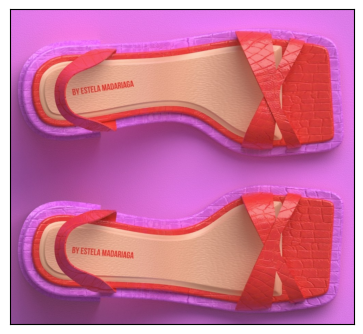

In [64]:
print_nodes(nodes)

In [65]:
query_str = "I want to know if there are any Sneakers and who is the author"
response , nodes = query_engine.custom_query(query_str)
response

' The image you\'ve provided appears to be a screenshot of some sort of text or data processing application, which seems to be analyzing or organizing information related to shoes or footwear, possibly for e-commerce purposes. It shows two pieces of information:\n\n1. A description field with "Sneakers" as the topic, suggesting that the items being discussed are sneakers or shoes.\n2. An author field with a name, indicating who created or contributed to this particular document or collection of data about sneakers.\n\nWithout more context, it\'s difficult to provide specific information about the content of the text itself or the intent behind creating such a document. However, given the provided query about sneakers and the author, it seems that you are interested in learning more about what the image is referring to and who might have created this collection of data on shoes or footwear.'

In [66]:
nodes

[NodeWithScore(node=TextNode(id_='5857a9d7-35cf-4abc-9f6b-d409533e9f4d', embedding=None, metadata={'file_path': 'd:\\project_tfg\\pocs\\poc_llamaindex_chromadb\\notebooks\\..\\data\\eml_txt_img\\5.txt', 'file_name': '5.txt', 'file_type': 'text/plain', 'file_size': 117, 'creation_date': '2024-12-04', 'last_modified_date': '2024-12-06'}, excluded_embed_metadata_keys=['file_name', 'file_type', 'file_size', 'creation_date', 'last_modified_date', 'last_accessed_date'], excluded_llm_metadata_keys=['file_name', 'file_type', 'file_size', 'creation_date', 'last_modified_date', 'last_accessed_date'], relationships={<NodeRelationship.SOURCE: '1'>: RelatedNodeInfo(node_id='fe771f58-6f61-4e6b-9586-b439da3bf8a0', node_type='4', metadata={'file_path': 'd:\\project_tfg\\pocs\\poc_llamaindex_chromadb\\notebooks\\..\\data\\eml_txt_img\\5.txt', 'file_name': '5.txt', 'file_type': 'text/plain', 'file_size': 117, 'creation_date': '2024-12-04', 'last_modified_date': '2024-12-06'}, hash='43ca77b0ccaaa27a37fc0

**Node ID:** 5857a9d7-35cf-4abc-9f6b-d409533e9f4d<br>**Similarity:** 0.6489903089080453<br>**Text:** Peach and White Colors Sneakers from the Spring and Summer Women's Collection designed by Estela ...<br>

**Node ID:** cd014b68-35ec-4575-aa50-4287776745f5<br>**Similarity:** 0.6299476197434326<br>**Text:** White and Black Colors Mesh Boot from the Spring and Summer Women's Collection designed by Estela...<br>

**Node ID:** dcd33026-53b2-46a9-94ea-1b483baabc37<br>**Similarity:** 0.5999308752789643<br>**Text:** Pink and Red Colors Sandals from the Spring and Summer Women's Collection designed by Estela Mada...<br>

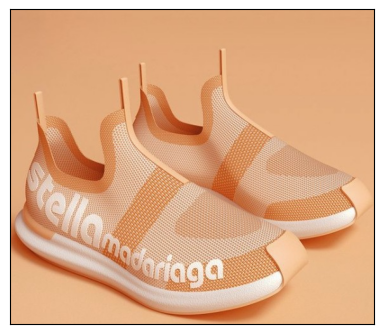

In [67]:
print_nodes(nodes)

In [68]:
query_str = "I want to know if there are Black Boots with Floral Embroidery"
response , nodes = query_engine.custom_query(query_str)
response

' Yes, there is a pair of black boots in the image that have floral embroidery on them. The text reads "Black boots with floral embroidery."'

In [69]:
nodes

[NodeWithScore(node=TextNode(id_='5b6d7eb0-63f3-4a05-b3bc-b94887b683d9', embedding=None, metadata={'file_path': 'd:\\project_tfg\\pocs\\poc_llamaindex_chromadb\\notebooks\\..\\data\\eml_txt_img\\1.txt', 'file_name': '1.txt', 'file_type': 'text/plain', 'file_size': 143, 'creation_date': '2024-12-04', 'last_modified_date': '2024-12-06'}, excluded_embed_metadata_keys=['file_name', 'file_type', 'file_size', 'creation_date', 'last_modified_date', 'last_accessed_date'], excluded_llm_metadata_keys=['file_name', 'file_type', 'file_size', 'creation_date', 'last_modified_date', 'last_accessed_date'], relationships={<NodeRelationship.SOURCE: '1'>: RelatedNodeInfo(node_id='018b1cad-f986-401b-99b9-f7c43ba1dcee', node_type='4', metadata={'file_path': 'd:\\project_tfg\\pocs\\poc_llamaindex_chromadb\\notebooks\\..\\data\\eml_txt_img\\1.txt', 'file_name': '1.txt', 'file_type': 'text/plain', 'file_size': 143, 'creation_date': '2024-12-04', 'last_modified_date': '2024-12-06'}, hash='92c65c86b26ad580c06c8

**Node ID:** 5b6d7eb0-63f3-4a05-b3bc-b94887b683d9<br>**Similarity:** 0.674739875787822<br>**Text:** Blue Denim Fabric Cowboy Boots with Camel Floral Embroidery from the Spring and Summer Women's Co...<br>

**Node ID:** cd014b68-35ec-4575-aa50-4287776745f5<br>**Similarity:** 0.6622000729565914<br>**Text:** White and Black Colors Mesh Boot from the Spring and Summer Women's Collection designed by Estela...<br>

**Node ID:** addfa27f-696c-4b4f-80f0-751492a113a9<br>**Similarity:** 0.6598720980333258<br>**Text:** Black Denim Fabric Cowboy Boots with Red and Pink Floral Embroidery from the Spring and Summer Wo...<br>

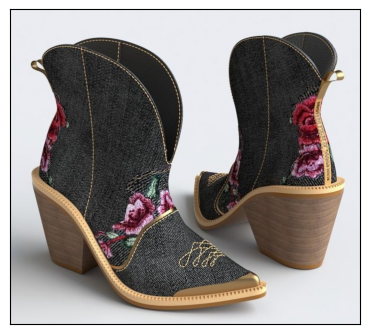

In [70]:
print_nodes(nodes)